In [4]:
import torch

print(torch.cuda.is_available())
print(next(model.parameters()).device)
device = torch.device("cuda")

True
cpu


True
cuda:0
cuda:0


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


0 0.5667611956596375
1000 0.11757861077785492
2000 0.04374384507536888
3000 0.014836565591394901
4000 0.00911614391952753
5000 0.00437511969357729
6000 0.002436285838484764
7000 0.002882912289351225
8000 0.001376515137962997
9000 0.0010735932737588882


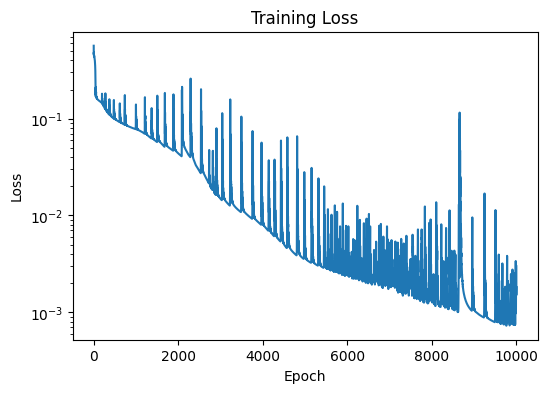

In [5]:
#PART A
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

N_f = 10000
N_b = 200
N_i = 100

x_f = (2*torch.rand(N_f,1)-1).detach().requires_grad_(True)
t_f = torch.rand(N_f,1).detach().requires_grad_(True)


t_b = torch.rand(N_b//2,1)

x_b0 = -torch.ones_like(t_b)
x_b1 = torch.ones_like(t_b)

x_i = (2*torch.rand(N_i,1)-1)
t_i = torch.zeros_like(x_i)

# Intial Condition
# u(x,0)=sin(pi x)

u_i = -torch.sin(np.pi*x_i)

class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2,100),
            nn.Tanh(),

            nn.Linear(100,100),
            nn.Tanh(),

            nn.Linear(100,100),
            nn.Tanh(),

            nn.Linear(100,100),
            nn.Tanh(),

            nn.Linear(100,1)
        )

    def forward(self,x,t):
        XT = torch.cat([x,t],dim=1)
        return self.net(XT)

model = PINN().to(device)

x_f = x_f.to(device)
t_f = t_f.to(device)

x_b0 = x_b0.to(device)
x_b1 = x_b1.to(device)
t_b = t_b.to(device)

x_i = x_i.to(device)
t_i = t_i.to(device)
u_i = u_i.to(device)


print(torch.cuda.is_available())
print(next(model.parameters()).device)
print(x_f.device)

nu = 0.01/np.pi

def pde_residual(model,x,t):
    u = model(x,t)
    u_x = torch.autograd.grad(u,x,grad_outputs=torch.ones_like(u),create_graph=True)[0]
    u_t = torch.autograd.grad(u,t,grad_outputs=torch.ones_like(u),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x,x,grad_outputs=torch.ones_like(u_x),create_graph=True)[0]
    f = u_t + u*u_x - nu*u_xx
    return f

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

losses = []


for epoch in range(10000):
    optimizer.zero_grad()

    f = pde_residual(model,x_f,t_f)
    loss_f = torch.mean(f**2)

    u_b0 = model(x_b0,t_b)
    u_b1 = model(x_b1,t_b)

    loss_b = (torch.mean(u_b0**2)+torch.mean(u_b1**2))
    u_pred_i = model(x_i,t_i)
    loss_i = ((u_pred_i-u_i)**2).mean()
    loss = loss_f + loss_b + loss_i

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 1000 == 0:
        print(epoch, loss.item())


plt.figure(figsize=(6,4))
plt.plot(losses)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [6]:
from google.colab import files

uploaded = files.upload()

Saving burgers_shock.mat to burgers_shock.mat
Saving Butcher_IRK50.txt to Butcher_IRK50.txt


In [7]:
import scipy.io

data = scipy.io.loadmat("burgers_shock.mat")

x = data["x"]
t = data["t"]
usol = data["usol"]

In [12]:
X, T = np.meshgrid(
    x.flatten(),
    t.flatten(),
    indexing="ij"
)

U_exact = usol
X_flat = X.reshape(-1,1)
T_flat = T.reshape(-1,1)

X_test = torch.tensor(
    X_flat,
    dtype=torch.float32,
    device=device
)

T_test = torch.tensor(
    T_flat,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():
    U_pred = model(X_test, T_test).cpu().numpy()

U_pred = U_pred.reshape(X.shape)


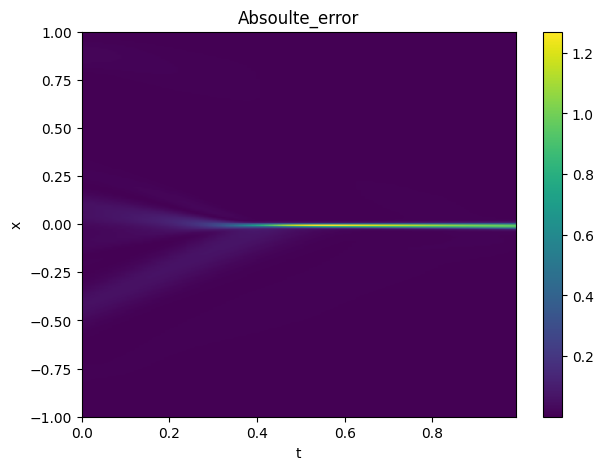

L2 error(Soft): 0.11926906802736635


In [13]:
plt.figure(figsize=(7,5))
plt.imshow(
    abs(U_pred-U_exact),
    extent=[t.min(),t.max(),x.min(),x.max()],
    aspect="auto",
    origin="lower"
)
plt.xlabel("t")
plt.ylabel("x")
plt.title("Absoulte_error")
plt.colorbar()
plt.show()

L2_error_Soft = (
    np.linalg.norm(U_pred - U_exact)
    / np.linalg.norm(U_exact)
)
print("L2 error(Soft):",L2_error_Soft)

In [14]:
print(U_pred.shape)
print(U_exact.shape)
print(U_pred.min(), U_pred.max())
print(U_exact.min(), U_exact.max())

(256, 100)
(256, 100)
-1.0014819 0.97802454
-0.9999810273487268 0.9999810273487268


In [15]:
#PART B

class PINN_Hard(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2,100),
            nn.Tanh(),

            nn.Linear(100,100),
            nn.Tanh(),

            nn.Linear(100,100),
            nn.Tanh(),

            nn.Linear(100,100),
            nn.Tanh(),

            nn.Linear(100,1)
        )

    def forward(self,x,t):
        XT = torch.cat([x,t],dim=1)
        N = self.net(XT)

        # HARD BC
        u = (1 - x**2)*N

        return u

In [18]:
model_Hard = PINN_Hard().to(device)

optimizer = torch.optim.Adam(
    model_Hard.parameters(),
    lr=1e-3
)

losses_Hard = []

for epoch in range(10000):
    optimizer.zero_grad()
    f = pde_residual(model_Hard,x_f,t_f)
    loss_f = torch.mean(f**2)
    u_pred_i = model_Hard(x_i,t_i)
    loss_i = ((u_pred_i-u_i)**2).mean()

    loss = loss_f + loss_i
    loss.backward()
    optimizer.step()
    losses_Hard.append(loss.item())

    if epoch % 1000 == 0:
        print(epoch, loss.item())

0 0.5123723745346069
1000 0.09170141816139221
2000 0.00680453609675169
3000 0.003458952996879816
4000 0.002522642258554697
5000 0.0013161629904061556
6000 0.0005634774570353329
7000 0.001258113537915051
8000 0.00018870104395318776
9000 0.0007783207111060619


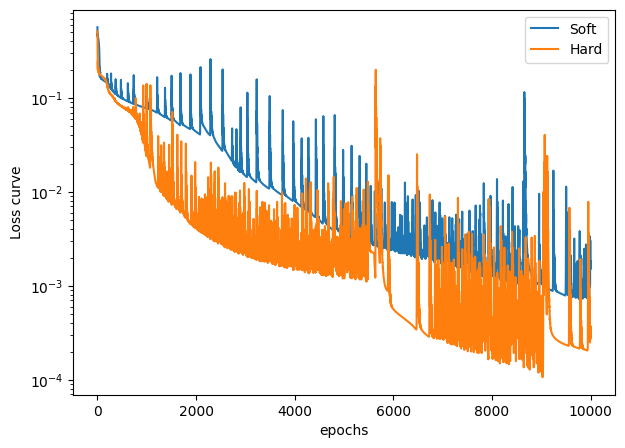

In [19]:
plt.figure(figsize=(7,5))
plt.plot(losses,label="Soft")
plt.plot(losses_Hard,label="Hard")
plt.legend()
plt.xlabel("epochs")
plt.yscale("log")
plt.ylabel("Loss curve")
plt.show()


In [24]:
with torch.no_grad():
    u_pred_Hard = model_Hard(X_test, T_test).cpu().numpy()

u_pred_Hard = u_pred_Hard.reshape(X.shape)


L2_error_Hard = (np.linalg.norm(u_pred_Hard - U_exact)/ np.linalg.norm(U_exact))

import pandas as pd
df = pd.DataFrame({
    "Method": ["Soft BC", "Hard BC"],
    "Final L2 Error": [L2_error_Soft, L2_error_Hard]
})

display(df)
#Hard BC achieved a lower L² error because the boundary conditions were enforced exactly by the network architecture,
#whereas Soft BC had to learn them through the loss function; however, the relative performance may differ on other PDEs depending on the geometry and optimization landscape.

,Method,Final L2 Error
0,Soft BC,0.119269
1,Hard BC,0.108908


In [ ]:
# PART C
# 1st case would be where we are asked to estimate parameters given data, then PINN is a better option than FEM because we can optimse
#both neural network and unknown parameter can be optimised together one example is estimating thermal conducivity using Temperature profile in spatial and time domain.

#2nd case is when the mesh generation is difficult like when the domain is a complicated geometry in n-dimensionsial space, here PINN will have advantage over FEM
#because PINN donot rquire mesh generation and requires only enforces PDE over sample points.